<a href="https://colab.research.google.com/github/panaddatappoomee/food-selection-data-science/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ขั้นที่ 1 — เตรียมข้อมูล
ข้อมูลหนังสือ : กำหนดรหัสหนังสือ(D000-001ถึงD900-015), หมวดหมู่(D000-D900), ชื่อผู้แต่ง, ชื่อหนังสือ

ข้อมูลสมาชิก : กำหนดรหัสสมาชิก(PS0001-PT0050), หมวดหมู่สมาชิก(นักศึกษา,อาจารย์)

ข้อมูลหลักที่ต้องเก็บ: หนังสือ, สมาชิก, การยืมคืน
คุณสมบัติ
หนังสือ: รหัสหนังสือ, ชื่อเรื่อง, ชื่อผู้แต่ง, หมวดหมู่, สถานะ(ว่าง/ถูกยืม)

สมาชิก: รหัสสมาชิก, ชื่อ, ประเภทสมาชิก(นักศึกษา/อาจารย์), จำนวนวันที่ยืมได้

การยืม: รหัสการยืม, หนังสือที่ยืม, สมาชิกที่ยืม, วันที่ยืม, กำหนดคืน, วันที่คืนจริง

หน้าที่
หนังสือ: ยืม, คืน

การยืม: คำนวณค่าปรับ, บันทึกการคืน

การตัดสินใจหรือคำนวณที่ซับซ้อน
ระยะเวลาการยืมต่างกัน นักศึกษายืมได้ 14 วัน อาจารย์ยืมได้ 30 วัน

ค่าปรับตามจำนวนวันที่คืนช้า 5บาทต่อวัน

In [ ]:
!pip install openpyxl
import pandas as pd

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. ติดตั้งฟอนต์ภาษาไทยลงในระบบ Colab
!apt-get -y install fonts-thai-tlwg > /dev/null 2>&1

# 2. โหลดไฟล์ฟอนต์เข้า Memory และตั้งค่า font_prop
font_path = "/usr/share/fonts/truetype/tlwg/Laksaman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 3. ตั้งค่า Default ให้ Matplotlib รู้จักฟอนต์และรองรับเครื่องหมายลบ
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ขั้นที่ 2 — ออกแบบ Class

In [ ]:
import random
from datetime import datetime, timedelta

In [ ]:
class Book:
    def __init__(self, book_id, title, author, category_code, category_name, status="ว่าง"):
        self.book_id = book_id
        self.title = title
        self.author = author
        self.category_code = category_code
        self.category_name = category_name
        self.is_available = (status == "ว่าง")

    def borrow(self):
        """เปลี่ยนสถานะเป็นถูกยืม"""
        self.is_available = False

    def return_book(self):
        """เปลี่ยนสถานะกลับเป็นว่าง"""
        self.is_available = True


class Member:
    def __init__(self, member_id, name, member_type, loan_period_days):
        self.member_id = member_id
        self.name = name
        self.member_type = member_type
        self.loan_period_days = loan_period_days


class BookLoan:
    FINE_PER_DAY = 5

    def __init__(self, loan_id, book, member, borrow_date):
        self.loan_id = loan_id
        self.book = book
        self.member = member
        self.borrow_date = borrow_date

        # กำหนดวันส่งคืนตามสิทธิ์สมาชิก
        self.due_date = borrow_date + timedelta(days=member.loan_period_days)
        self.return_date = None

        # บันทึกว่าหนังสือถูกยืมทันทีเมื่อสร้างรายการ
        self.book.borrow()

    def calculate_late_fee(self):
        """คำนวณค่าปรับถ้าคืนช้ากว่ากำหนด"""
        if self.return_date is not None and self.return_date > self.due_date:
            late_days = (self.return_date - self.due_date).days
            return late_days * self.FINE_PER_DAY

        return 0

    def mark_returned(self, return_date):
        """บันทึกว่าคืนหนังสือแล้ว"""

        self.return_date = return_date
        self.book.return_book()

# ขั้นที่ 3 — เขียนฟังก์ชันช่วยงาน (Helper Functions)

In [ ]:
import pandas as pd


def load_books(csv_path):
    """โหลดหนังสือจากไฟล์ CSV แล้วสร้างเป็น Book object"""

    df = pd.read_csv("/content/books.csv")

    return [
        Book(
            row.book_id,
            row.title,
            row.author,
            row.category_code,
            row.category_name,
            row.status
        )
        for row in df.itertuples(index=False)
    ]


def load_members(csv_path):
    """โหลดสมาชิกจากไฟล์ CSV แล้วสร้างเป็น Member object"""

    df = pd.read_csv("/content/members.csv")

    return [
        Member(
            row.member_id,
            row.name,
            row.member_type,
            row.loan_period_days
        )
        for row in df.itertuples(index=False)
    ]


def random_borrow_date(start_date, days_range=300):
    """ฟังก์ชัน: สุ่มวันที่เริ่มยืมหนังสือจากวันที่กำหนด -> คืนค่าเป็น datetime"""

    offset = random.randint(0, days_range)

    return start_date + timedelta(days=offset)


def decide_return_outcome(
    never_return_probability=0.20,
    late_probability=0.25
):
    """ฟังก์ชัน: สุ่มสถานะผลลัพธ์การคืนหนังสือตามความน่าจะเป็น -> คืนค่าเป็น string"""

    r = random.random()

    if r < never_return_probability:
        return "not_returned"

    elif r < never_return_probability + late_probability:
        return "late"

    else:
        return "on_time"


def calculate_return_date(due_date, outcome):
    """ฟังก์ชัน: คำนวณวันที่นำหนังสือมาคืนจริงตามสถานะผลลัพธ์ -> คืนค่าเป็น datetime หรือ None"""

    if outcome == "not_returned":
        return None

    elif outcome == "late":
        return due_date + timedelta(days=random.randint(1, 10))

    else:
        return due_date - timedelta(days=random.randint(0, 5))

# ทดสอบฟังก์ชันทีละตัว ก่อนเอาไปประกอบเป็นกระบวนการ

In [ ]:
print("ทดสอบที่ 1: load_books และ load_members จากไฟล์จริง")
try:
    books = load_books("/content/books.csv")
    members = load_members("/content/members.csv")

    print(f"✅ โหลดหนังสือสำเร็จทั้งหมด: {len(books)} เล่ม")
    print(
        f"   ตัวอย่างเล่มแรก: {books[0].title} (สถานะพร้อมยืม: {books[0].is_available})"
    )

    print(f"✅ โหลดสมาชิกสำเร็จทั้งหมด: {len(members)} คน")
    print(
        f"   ตัวอย่างคนแรก: {members[0].name} (ยืมได้ {members[0].loan_period_days} วัน)"
    )
except FileNotFoundError as e:
    print(
        f"❌ ไม่พบไฟล์ CSV! กรุณาเช็กชื่อและพาธไฟล์อีกครั้ง: {e.filename}"
    )
except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดในการอ่านไฟล์: {e}")

print("-" * 50)

ทดสอบที่ 1: load_books และ load_members จากไฟล์จริง
✅ โหลดหนังสือสำเร็จทั้งหมด: 150 เล่ม
   ตัวอย่างเล่มแรก: พื้นฐานการเขียนโปรแกรมด้วย Python (สถานะพร้อมยืม: True)
✅ โหลดสมาชิกสำเร็จทั้งหมด: 350 คน
   ตัวอย่างคนแรก: รติ (ยืมได้ 14 วัน)
--------------------------------------------------


In [ ]:
print("ทดสอบที่ 2: random_borrow_date")
start_date = datetime(2026, 1, 1)
sample_borrow_date = random_borrow_date(start_date, days_range=30)
print(f"วันเริ่มสุ่ม: {start_date.strftime('%Y-%m-%d')}")
print(f"วันที่สุ่มได้: {sample_borrow_date.strftime('%Y-%m-%d')}")
print("-" * 50)

ทดสอบที่ 2: random_borrow_date
วันเริ่มสุ่ม: 2026-01-01
วันที่สุ่มได้: 2026-01-18
--------------------------------------------------


In [ ]:
print("ทดสอบที่ 3: decide_return_outcome")
results = [decide_return_outcome() for _ in range(5)]
print(f"ผลการสุ่มคืนหนังสือ 5 ครั้ง: {results}")
print("-" * 50)

ทดสอบที่ 3: decide_return_outcome
ผลการสุ่มคืนหนังสือ 5 ครั้ง: ['on_time', 'on_time', 'on_time', 'not_returned', 'not_returned']
--------------------------------------------------


In [ ]:
print("ทดสอบที่ 4: calculate_return_date")
due_date = datetime(2026, 8, 10)

return_on_time = calculate_return_date(due_date, "on_time")
return_late = calculate_return_date(due_date, "late")
return_never = calculate_return_date(due_date, "not_returned")

print(f"กำหนดคืน: {due_date.strftime('%Y-%m-%d')}")
print(
    f"กรณี คืนตรงเวลา (on_time): {return_on_time.strftime('%Y-%m-%d') if return_on_time else 'ไม่คืน'}"
)
print(
    f"กรณี คืนสาย (late): {return_late.strftime('%Y-%m-%d') if return_late else 'ไม่คืน'}"
)
print(f"กรณี ไม่คืนเลย (not_returned): {return_never}")
print("-" * 50)

ทดสอบที่ 4: calculate_return_date
กำหนดคืน: 2026-08-10
กรณี คืนตรงเวลา (on_time): 2026-08-09
กรณี คืนสาย (late): 2026-08-15
กรณี ไม่คืนเลย (not_returned): None
--------------------------------------------------


In [ ]:
import random
from datetime import datetime, timedelta


def format_currency(amount, symbol="บาท"):
    """จัดรูปแบบตัวเลขเป็นสตริงเงิน เช่น 15.00 บาท"""
    return f"{amount:,.2f} {symbol}"


def simulate_member_visit(loan_id, member, book):
    """รับข้อมูลรหัสรายการ, สมาชิก, และหนังสือ -> จำลองกระบวนการยืมและคืน"""
    # กำหนดวันที่ยืม
    borrow_date = datetime(2025, 1, 1) + timedelta(days=random.randint(0, 30))

    # สร้างรายการยืม
    loan = BookLoan(loan_id, book, member, borrow_date)

    # ประมวลผลการคืนหนังสือ
    outcome = decide_return_outcome()
    return_date = calculate_return_date(loan.due_date, outcome)

    if return_date is not None:
        loan.mark_returned(return_date)

    # แสดงผลลัพธ์แบบเล่าเรื่อง
    print("=" * 60)
    print(
        f"📖 รายการ #{loan.loan_id}: คุณ '{member.name}' (รหัสสมาชิก:"
        f" {member.member_id}) เข้ามายืมหนังสือ"
    )
    print(
        f"📚 หนังสือที่เลือก: '{book.title}' (รหัสหนังสือ: {book.book_id}) โดย"
        f" {book.author}"
    )
    print(f"🗓️ วันที่ยืม: {borrow_date.strftime('%Y-%m-%d')}")
    print(f"⏰ กำหนดคืน: {loan.due_date.strftime('%Y-%m-%d')}")

    if loan.return_date:
        late_fee = loan.calculate_late_fee()
        print(
            f"✅ คืนหนังสือแล้วในวันที่ {loan.return_date.strftime('%Y-%m-%d')}"
        )
        if late_fee > 0:
            print(
                f"⚠️ เกินกำหนดส่งคืน! ค่าปรับสุทธิ: {format_currency(late_fee)}"
            )
        else:
            print("🎉 คืนตรงเวลา ไม่มีค่าปรับ")
    else:
        print("⚠️ ยังไม่คืนหนังสือ")
    print("=" * 60)

    return loan

In [ ]:
# --- เรียกใช้งานจริงกับสมาชิก 1 คน ---

# 1. โหลดข้อมูลจาก CSV
members = load_members("members.csv")
books = load_books("books.csv")

# 2. เลือกสมาชิกคนแรก และสุ่มหนังสือ 1 เล่มจาก CSV
member_a = members[0]
book_a = random.choice(books)

# 3. เรียกใช้งานฟังก์ชันจำลองสำหรับสมาชิกคนแรก (ออเดอร์ #1)
order_a = simulate_member_visit(loan_id="L001", member=member_a, book=book_a)

📖 รายการ #L001: คุณ 'รติ' (รหัสสมาชิก: PS0001) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'การแต่งเพลงเบื้องต้น' (รหัสหนังสือ: D700-011) โดย นักแต่งเพลง ทำนองไพเราะ
🗓️ วันที่ยืม: 2025-01-29
⏰ กำหนดคืน: 2025-02-12
✅ คืนหนังสือแล้วในวันที่ 2025-02-09
🎉 คืนตรงเวลา ไม่มีค่าปรับ


In [ ]:
members = load_members("members.csv")
books = load_books("books.csv")

# สุ่มเลือกสมาชิกที่จะเดินเข้ามาในวันนี้จำนวน 5 คน
walk_in_members = random.sample(members, k=min(5, len(members)))

completed_orders = []  # เก็บผลลัพธ์ของทุกออเดอร์ที่จำลองในรอบนี้

# เรียก simulate_member_visit() ซ้ำหลายๆ ครั้งผ่าน loop
for i, mem in enumerate(walk_in_members, start=1):
    loan_code = f"L{i:03d}"  # สร้างรหัสเช่น L001, L002, L003...
    selected_book = random.choice(books)  # สุ่มหนังสือที่สมาชิกเลือก

    # เรียกใช้ฟังก์ชันจำลอง
    order = simulate_member_visit(
        loan_id=loan_code, member=mem, book=selected_book
    )
    completed_orders.append(order)

print("=" * 60)
print(
    f"🏁 จบรอบสาธิต — วันนี้มีสมาชิกเข้ามาใช้บริการห้องสมุดทั้งหมด"
    f" {len(completed_orders)} คน"
)

📖 รายการ #L001: คุณ 'เจมส์' (รหัสสมาชิก: PS0047) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'ดนตรีไทยเบื้องต้น' (รหัสหนังสือ: D700-002) โดย ระนาด เสียงเพราะ
🗓️ วันที่ยืม: 2025-01-02
⏰ กำหนดคืน: 2025-01-16
✅ คืนหนังสือแล้วในวันที่ 2025-01-22
⚠️ เกินกำหนดส่งคืน! ค่าปรับสุทธิ: 30.00 บาท
📖 รายการ #L002: คุณ 'โมเน่' (รหัสสมาชิก: PS0114) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'ภาษาศาสตร์เบื้องต้น' (รหัสหนังสือ: D400-001) โดย รุ่งนภา ภาษาไทย
🗓️ วันที่ยืม: 2025-01-13
⏰ กำหนดคืน: 2025-01-27
✅ คืนหนังสือแล้วในวันที่ 2025-01-25
🎉 คืนตรงเวลา ไม่มีค่าปรับ
📖 รายการ #L003: คุณ 'เปรม' (รหัสสมาชิก: PS0231) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'การพัฒนาชุมชน' (รหัสหนังสือ: D300-013) โดย ลัดดา ชุมชนเข้มแข็ง
🗓️ วันที่ยืม: 2025-01-01
⏰ กำหนดคืน: 2025-01-15
✅ คืนหนังสือแล้วในวันที่ 2025-01-17
⚠️ เกินกำหนดส่งคืน! ค่าปรับสุทธิ: 10.00 บาท
📖 รายการ #L004: คุณ 'พีพี' (รหัสสมาชิก: PS0179) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'เคมีอินทรีย์เบื้องต้น' (รหัสหนังสือ: D500-011) โดย คาร์บอน โมเลกุล
🗓️ วันที่ยืม: 2025-01-26
⏰ กำหนดค

In [ ]:
# รวมรายการแรก (L001) เข้ากับออเดอร์ที่เหลือจากในลูป (L002, L003, L004)
all_demo_orders = [order_a] + completed_orders

print("=" * 60)
print(f"📊 สรุปภาพรวมการจำลองทั้งหมด:")
print(f"   จำนวนรายการทั้งหมด: {len(all_demo_orders)} รายการ")
for order in all_demo_orders:
    fee = order.calculate_late_fee()
    fee_str = format_currency(fee) if fee > 0 else "ไม่มีค่าปรับ"
    print(f"   • รหัส: {order.loan_id} | สมาชิก: {order.member.name} | หนังสือ: {order.book.title} | ค่าปรับ: {fee_str}")
print("=" * 60)

📊 สรุปภาพรวมการจำลองทั้งหมด:
   จำนวนรายการทั้งหมด: 6 รายการ
   • รหัส: L001 | สมาชิก: รติ | หนังสือ: การแต่งเพลงเบื้องต้น | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L001 | สมาชิก: เจมส์ | หนังสือ: ดนตรีไทยเบื้องต้น | ค่าปรับ: 30.00 บาท
   • รหัส: L002 | สมาชิก: โมเน่ | หนังสือ: ภาษาศาสตร์เบื้องต้น | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L003 | สมาชิก: เปรม | หนังสือ: การพัฒนาชุมชน | ค่าปรับ: 10.00 บาท
   • รหัส: L004 | สมาชิก: พีพี | หนังสือ: เคมีอินทรีย์เบื้องต้น | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L005 | สมาชิก: มะนาว | หนังสือ: ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล | ค่าปรับ: ไม่มีค่าปรับ


In [ ]:
import pandas as pd

summary_rows = [
    {
        "loan_id": o.loan_id,
        "member_id": o.member.member_id,
        "member_name": o.member.name,
        "book_title": o.book.title,
        "borrow_date": o.borrow_date.strftime("%Y-%m-%d"),
        "due_date": o.due_date.strftime("%Y-%m-%d"),
        "return_date": (
            o.return_date.strftime("%Y-%m-%d") if o.return_date else "ยังไม่คืน"
        ),
        "late_fee": o.calculate_late_fee(),
        "status": "คืนแล้ว" if o.return_date else "ค้างส่ง",
    }
    for o in all_demo_orders
]

demo_summary_df = pd.DataFrame(summary_rows)
demo_summary_df

,loan_id,member_id,member_name,book_title,borrow_date,due_date,return_date,late_fee,status
0,L001,PS0001,รติ,การแต่งเพลงเบื้องต้น,2025-01-29,2025-02-12,2025-02-09,0,คืนแล้ว
1,L001,PS0047,เจมส์,ดนตรีไทยเบื้องต้น,2025-01-02,2025-01-16,2025-01-22,30,คืนแล้ว
2,L002,PS0114,โมเน่,ภาษาศาสตร์เบื้องต้น,2025-01-13,2025-01-27,2025-01-25,0,คืนแล้ว
3,L003,PS0231,เปรม,การพัฒนาชุมชน,2025-01-01,2025-01-15,2025-01-17,10,คืนแล้ว
4,L004,PS0179,พีพี,เคมีอินทรีย์เบื้องต้น,2025-01-26,2025-02-09,ยังไม่คืน,0,ค้างส่ง
5,L005,PS0014,มะนาว,ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล,2025-01-10,2025-01-24,2025-01-21,0,คืนแล้ว


# ขั้นที่ 4 — จำลองข้อมูลทีละรายการด้วย Loop

In [ ]:
import random
from datetime import datetime, timedelta
import pandas as pd

# 1. นิยามฟังก์ชัน (แก้ไขจุดที่พิมพ์ผิดแล้ว)
def simulate_borrow_batch(
    num_records=350,
    start_date=datetime(2026, 1, 1),
    days_range=180,
    seed=None,
):
    if seed is not None:
        random.seed(seed)

    members = load_members("members.csv")
    books = load_books("books.csv")

    records = []

    for i in range(1, num_records + 1):
        loan_id = f"L{i:04d}"

        member = random.choice(members)
        book = random.choice(books)
        borrow_date = start_date + timedelta(
            days=random.randint(0, days_range)
        )

        loan = BookLoan(loan_id, book, member, borrow_date)
        outcome = decide_return_outcome()
        return_date = calculate_return_date(loan.due_date, outcome)

        if return_date is not None:
            loan.mark_returned(return_date)

        records.append({
            "loan_id": loan.loan_id,
            "member_id": loan.member.member_id,
            "member_name": loan.member.name,
            "member_type": loan.member.member_type,
            "book_id": loan.book.book_id,
            "book_title": loan.book.title,
            "borrow_date": loan.borrow_date.strftime("%Y-%m-%d"),
            "due_date": loan.due_date.strftime("%Y-%m-%d"),
            "return_date": (
                loan.return_date.strftime("%Y-%m-%d")
                if loan.return_date
                else None
            ),
            "late_fee": loan.calculate_late_fee(),
            "status": "คืนแล้ว" if loan.return_date else "ค้างส่ง",
        })

    return pd.DataFrame(records)

df_loans_350 = simulate_borrow_batch(num_records=350, seed=42)

df_loans_350.head()

,loan_id,member_id,member_name,member_type,book_id,book_title,borrow_date,due_date,return_date,late_fee,status
0,L0001,PT0028,ใหญ่,อาจารย์,D100-014,จิตวิเคราะห์เบื้องต้น,2026-01-07,2026-02-06,2026-02-05,0,คืนแล้ว
1,L0002,PS0115,นิค,นักศึกษา,D200-006,ปรัชญาพุทธศาสนา,2026-01-27,2026-02-10,2026-02-06,0,คืนแล้ว
2,L0003,PS0045,โซล,นักศึกษา,D700-004,ศิลปะการแสดงไทย,2026-01-09,2026-01-23,None,0,ค้างส่ง
3,L0004,PS0112,มะปราง,นักศึกษา,D300-015,ความสัมพันธ์ระหว่างประเทศ,2026-05-10,2026-05-24,2026-05-20,0,คืนแล้ว
4,L0005,PS0102,เซญ่า,นักศึกษา,D900-005,ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้,2026-04-18,2026-05-02,2026-05-12,50,คืนแล้ว


# ขั้นที่ 5 — แปลง Object เป็นตาราง แล้วบันทึกเป็น CSV

In [ ]:
df_loans_350

,loan_id,member_id,member_name,member_type,book_id,book_title,borrow_date,due_date,return_date,late_fee,status
0,L0001,PT0028,ใหญ่,อาจารย์,D100-014,จิตวิเคราะห์เบื้องต้น,2026-01-07,2026-02-06,2026-02-05,0,คืนแล้ว
1,L0002,PS0115,นิค,นักศึกษา,D200-006,ปรัชญาพุทธศาสนา,2026-01-27,2026-02-10,2026-02-06,0,คืนแล้ว
2,L0003,PS0045,โซล,นักศึกษา,D700-004,ศิลปะการแสดงไทย,2026-01-09,2026-01-23,None,0,ค้างส่ง
3,L0004,PS0112,มะปราง,นักศึกษา,D300-015,ความสัมพันธ์ระหว่างประเทศ,2026-05-10,2026-05-24,2026-05-20,0,คืนแล้ว
4,L0005,PS0102,เซญ่า,นักศึกษา,D900-005,ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้,2026-04-18,2026-05-02,2026-05-12,50,คืนแล้ว
...,...,...,...,...,...,...,...,...,...,...,...
345,L0346,PS0230,สายธาร,นักศึกษา,D300-015,ความสัมพันธ์ระหว่างประเทศ,2026-05-17,2026-05-31,2026-06-08,40,คืนแล้ว
346,L0347,PS0100,กัปตัน,นักศึกษา,D600-005,โภชนาการและการทำอาหาร,2026-06-23,2026-07-07,2026-07-04,0,คืนแล้ว
347,L0348,PS0237,น้ำปั่น,นักศึกษา,D400-013,วัจนลีลาศาสตร์,2026-04-08,2026-04-22,2026-04-19,0,คืนแล้ว
348,L0349,PS0083,มะลิ,นักศึกษา,D300-007,สื่อสารมวลชนในยุคดิจิทัล,2026-06-04,2026-06-18,None,0,ค้างส่ง


# ขั้นที่ 6 — สร้างฐานข้อมูล SQLite จากข้อมูลเดียวกัน

In [ ]:
# 6.สร้าง SQLite Database
import sqlite3

df_books = pd.read_csv("books.csv")
df_members = pd.read_csv("members.csv")

conn = sqlite3.connect("library.db")

df_books.to_sql(
    "books",
    conn,
    if_exists="replace",
    index=False
)

df_members.to_sql(
    "members",
    conn,
    if_exists="replace",
    index=False
)

df_loans_350.to_sql("loans", conn, if_exists="replace", index=False)

check = pd.read_sql_query(
    "SELECT * FROM loans LIMIT 5",
    conn
)

print(check)



  loan_id member_id member_name member_type   book_id  \
0   L0001    PT0028        ใหญ่     อาจารย์  D100-014   
1   L0002    PS0115         นิค    นักศึกษา  D200-006   
2   L0003    PS0045         โซล    นักศึกษา  D700-004   
3   L0004    PS0112      มะปราง    นักศึกษา  D300-015   
4   L0005    PS0102       เซญ่า    นักศึกษา  D900-005   

                            book_title borrow_date    due_date return_date  \
0                จิตวิเคราะห์เบื้องต้น  2026-01-07  2026-02-06  2026-02-05   
1                      ปรัชญาพุทธศาสนา  2026-01-27  2026-02-10  2026-02-06   
2                      ศิลปะการแสดงไทย  2026-01-09  2026-01-23        None   
3            ความสัมพันธ์ระหว่างประเทศ  2026-05-10  2026-05-24  2026-05-20   
4  ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้  2026-04-18  2026-05-02  2026-05-12   

   late_fee   status  
0         0  คืนแล้ว  
1         0  คืนแล้ว  
2         0  ค้างส่ง  
3         0  คืนแล้ว  
4        50  คืนแล้ว  


# ขั้นที่ 7 — วิเคราะห์ข้อมูลด้วย pandas และ SQL

In [ ]:
# 6. วิเคราะห์ด้วย Pandas


# 1. ประกาศสร้างตัวแปร df_loans ก่อน
df_loans = simulate_borrow_batch(num_records=350, seed=42)

# 2. จากนั้นค่อยทำการ merge
df_merged = df_loans.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
)

In [ ]:
# Q1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby("category_name").agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values("total_loans", ascending=False)
print("Pandas Q1:", category_summary)

Pandas Q1:                            category_name  total_loans  total_late_fee
5                            วิทยาศาสตร์           43             270
7                    ศิลปะ และการบันเทิง           39             385
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           39             215
1            ประวัติศาสตร์ และภูมิศาสตร์           38             280
3                             ภาษาศาสตร์           38             225
6                                  ศาสนา           37             175
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           33             140
2                     ปรัชญา และจิตวิทยา           31             290
4                    วรรณคดี และวรรณกรรม           31             205
8                            สังคมศาสตร์           21             275


In [ ]:
# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby("member_type").agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values("avg_late_fee", ascending=False)
print("Pandas Q2:", member_type_summary)

Pandas Q2:   member_type  total_loans  avg_late_fee
1     อาจารย์           56      7.232143
0    นักศึกษา          294      6.989796


In [ ]:
# Q3: ใครคืนช้าที่สุด (Top late fee)
top_late = df_merged[df_merged["late_fee"] > 0].sort_values("late_fee", ascending=False)
print("Pandas Q3:", top_late.head())

Pandas Q3:     loan_id member_id member_name member_type   book_id  \
4     L0005    PS0102       เซญ่า    นักศึกษา  D900-005   
95    L0096    PS0224        โน้ต    นักศึกษา  D800-011   
104   L0105    PS0156         อาย    นักศึกษา  D400-014   
179   L0180    PS0039      มิกกี้    นักศึกษา  D200-011   
233   L0234    PS0197     น้ำอุ่น    นักศึกษา  D800-004   

                              book_title borrow_date    due_date return_date  \
4    ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้  2026-04-18  2026-05-02  2026-05-12   
95                   เรื่องสั้นแนวสืบสวน  2026-01-30  2026-02-13  2026-02-23   
104                ภาษาฝรั่งเศสเบื้องต้น  2026-02-23  2026-03-09  2026-03-19   
179                     ศาสนากับสังคมไทย  2026-01-01  2026-01-15  2026-01-25   
233                        บทกวีร่วมสมัย  2026-01-28  2026-02-11  2026-02-21   

     late_fee   status                category_name  
4          50  คืนแล้ว  ประวัติศาสตร์ และภูมิศาสตร์  
95         50  คืนแล้ว          วรรณคดี และวร

In [ ]:
# Q4: หนังสือหมวด D000 ถูกยืมล่าสุดเมื่อไหร่?
latest_d000 = df_merged[df_merged["category_name"] == "คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ"].sort_values("borrow_date", ascending=False)
print("Pandas Q4:", latest_d000.head())

Pandas Q4:     loan_id member_id member_name member_type   book_id  \
189   L0190    PT0001          อร     อาจารย์  D000-006   
11    L0012    PS0036      แม็กซ์    นักศึกษา  D000-012   
89    L0090    PS0115         นิค    นักศึกษา  D000-007   
196   L0197    PS0264       นาล่า    นักศึกษา  D000-001   
51    L0052    PS0051      มิ้นท์    นักศึกษา  D000-013   

                            book_title borrow_date    due_date return_date  \
189      การจัดการสารสนเทศในยุคดิจิทัล  2026-06-22  2026-07-22  2026-07-18   
11           คลาวด์คอมพิวติ้งเบื้องต้น  2026-06-19  2026-07-03  2026-07-08   
89        อัลกอริทึมและโครงสร้างข้อมูล  2026-06-18  2026-07-02        None   
196  พื้นฐานการเขียนโปรแกรมด้วย Python  2026-06-18  2026-07-02  2026-06-29   
51            การเขียนโปรแกรมเชิงวัตถุ  2026-06-16  2026-06-30  2026-06-30   

     late_fee   status                          category_name  
189         0  คืนแล้ว  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  
11         25  คืนแล้ว  คอมพิวเตอร์ ค

In [ ]:
# Q5: 5 สมาชิกที่ยืมบ่อยที่สุด
top_members = df_merged.groupby("member_name").agg(
    total_borrows=("loan_id", "count")
).reset_index().sort_values("total_borrows", ascending=False).head(5)
print("Pandas Q5:", top_members)

Pandas Q5:     member_name  total_borrows
2         กอล์ฟ              5
91        ฝันดี              5
61      น้ำปั่น              5
193       แชมป์              5
158         หยก              4


In [ ]:
# Q6: รายการที่ยังไม่คืน
not_returned = df_merged[df_merged["return_date"].isnull()][
    ["loan_id", "book_id", "member_id", "borrow_date", "due_date"]
].sort_values("due_date", ascending=True)

print("Pandas Q6:", not_returned.head())

Pandas Q6:     loan_id   book_id member_id borrow_date    due_date
291   L0292  D500-015    PS0174  2026-01-02  2026-01-16
266   L0267  D500-008    PS0122  2026-01-05  2026-01-19
2     L0003  D700-004    PS0045  2026-01-09  2026-01-23
53    L0054  D600-013    PS0110  2026-01-16  2026-01-30
280   L0281  D800-002    PS0079  2026-01-18  2026-02-01


In [ ]:
# 7. วิเคราะห์ด้วย SQL
# Q1: หมวดไหนถูกยืมมากที่สุด?
q1 = pd.read_sql_query("""
    SELECT b.category_name,
           COUNT(*) AS total_loans,
           SUM(l.late_fee) AS total_late_fee
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    GROUP BY b.category_name
    ORDER BY total_loans DESC;
""", conn)
print("SQL Q1:", q1)

SQL Q1:                            category_name  total_loans  total_late_fee
0                            วิทยาศาสตร์           43             270
1       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           39             215
2                    ศิลปะ และการบันเทิง           39             385
3                             ภาษาศาสตร์           38             225
4            ประวัติศาสตร์ และภูมิศาสตร์           38             280
5                                  ศาสนา           37             175
6  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           33             140
7                    วรรณคดี และวรรณกรรม           31             205
8                     ปรัชญา และจิตวิทยา           31             290
9                            สังคมศาสตร์           21             275


In [ ]:
# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
q2 = pd.read_sql_query("""
    SELECT m.member_type,
           COUNT(*) AS total_loans,
           AVG(l.late_fee) AS avg_late_fee
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.member_type
    ORDER BY avg_late_fee DESC;
""", conn)
print("SQL Q2:", q2)

SQL Q2:   member_type  total_loans  avg_late_fee
0     อาจารย์           56      7.232143
1    นักศึกษา          294      6.989796


In [ ]:
# Q3: ใครคืนช้าที่สุด (Top late fee)
q3 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, late_fee
    FROM loans
    WHERE late_fee > 0
    ORDER BY late_fee DESC;
""", conn)
print("SQL Q3:", q3.head())

SQL Q3:   loan_id   book_id member_id  late_fee
0   L0005  D900-005    PS0102        50
1   L0096  D800-011    PS0224        50
2   L0105  D400-014    PS0156        50
3   L0180  D200-011    PS0039        50
4   L0189  D000-007    PS0129        50


In [ ]:
# Q4: หนังสือหมวด D000 ถูกยืมล่าสุดเมื่อไหร่?
q4 = pd.read_sql_query("""
    SELECT l.loan_id, b.title, b.category_name, l.borrow_date
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    WHERE b.category_code = 'D000'
    ORDER BY l.borrow_date DESC;
""", conn)
print("SQL Q4:", q4.head())

SQL Q4:   loan_id                              title  \
0   L0190      การจัดการสารสนเทศในยุคดิจิทัล   
1   L0012          คลาวด์คอมพิวติ้งเบื้องต้น   
2   L0197  พื้นฐานการเขียนโปรแกรมด้วย Python   
3   L0090       อัลกอริทึมและโครงสร้างข้อมูล   
4   L0052           การเขียนโปรแกรมเชิงวัตถุ   

                           category_name borrow_date  
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2026-06-22  
1  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2026-06-19  
2  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2026-06-18  
3  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2026-06-18  
4  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2026-06-16  


In [ ]:
# Q5: 5 สมาชิกที่ยืมบ่อยที่สุด
q5 = pd.read_sql_query("""
    SELECT m.name, COUNT(*) AS total_borrows
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.name
    ORDER BY total_borrows DESC
    LIMIT 5;
""", conn)
print("SQL Q5:", q5)

SQL Q5:       name  total_borrows
0    แชมป์              5
1    ฝันดี              5
2  น้ำปั่น              5
3    กอล์ฟ              5
4    ไม้ที              4


In [ ]:
# Q6: รายการที่ยังไม่คืน
q6 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, borrow_date, due_date
    FROM loans
    WHERE return_date IS NULL
    ORDER BY due_date ASC;
""", conn)
print("SQL Q6:", q6.head())

SQL Q6:   loan_id   book_id member_id borrow_date    due_date
0   L0292  D500-015    PS0174  2026-01-02  2026-01-16
1   L0267  D500-008    PS0122  2026-01-05  2026-01-19
2   L0003  D700-004    PS0045  2026-01-09  2026-01-23
3   L0054  D600-013    PS0110  2026-01-16  2026-01-30
4   L0281  D800-002    PS0079  2026-01-18  2026-02-01


In [ ]:
# 7.วิเคราะห์ด้วย Pandas
df_merged = df_loans_350.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
)

df_merged = df_merged.merge(
    df_members[["member_id", "member_type", "name"]],
    on="member_id",
    how="left"
)

#คำถามที่ 1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby(
    "category_name"
).agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values(
    "total_loans",
    ascending=False
)

print(category_summary)

#คำถามที่ 2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby(
    "member_type"
).agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values(
    "avg_late_fee",
    ascending=False
)

print(member_type_summary)

                           category_name  total_loans  total_late_fee
5                            วิทยาศาสตร์           43             270
7                    ศิลปะ และการบันเทิง           39             385
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           39             215
1            ประวัติศาสตร์ และภูมิศาสตร์           38             280
3                             ภาษาศาสตร์           38             225
6                                  ศาสนา           37             175
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           33             140
2                     ปรัชญา และจิตวิทยา           31             290
4                    วรรณคดี และวรรณกรรม           31             205
8                            สังคมศาสตร์           21             275


KeyError: 'member_type'

# ขั้นที่ 8 — สร้างกราฟและสรุปผล

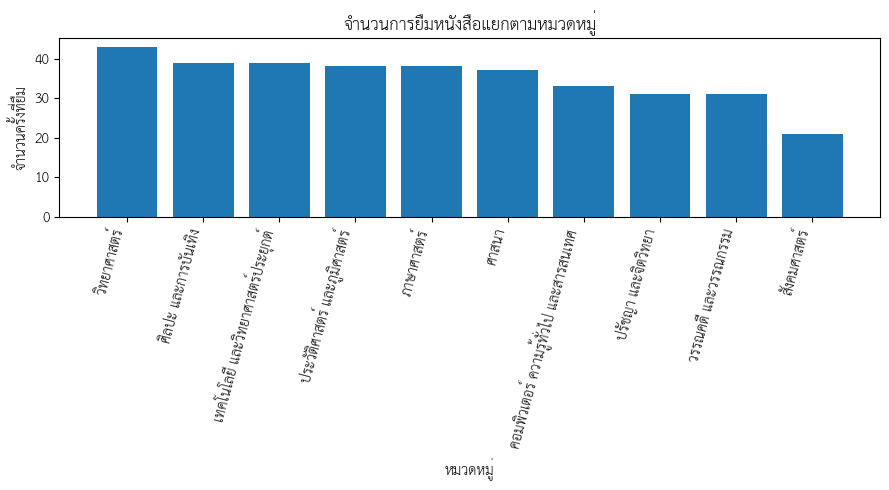

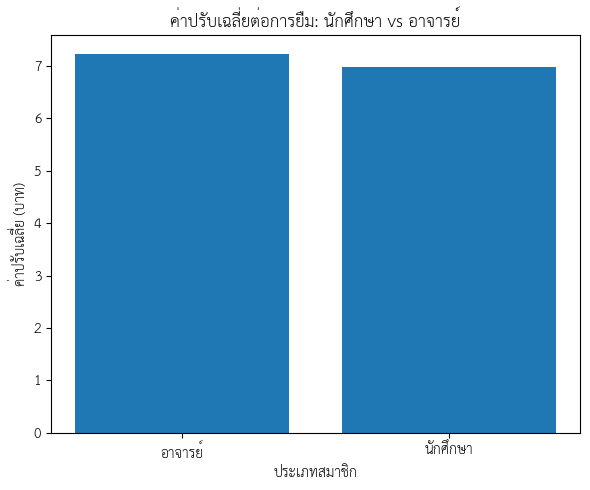

KeyError: 'name'

<Figure size 800x500 with 0 Axes>

In [ ]:
#สร้างกราฟ 3 รูป
import matplotlib.pyplot as plt
#กราฟที่ 1 — จำนวนการยืมตามหมวดหมู่
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["category_name"],
    category_summary["total_loans"]
)

plt.title("จำนวนการยืมหนังสือแยกตามหมวดหมู่")
plt.xlabel("หมวดหมู่")
plt.ylabel("จำนวนครั้งที่ยืม")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

#กราฟที่ 2 — ค่าปรับเฉลี่ยตามประเภทสมาชิก
plt.figure(figsize=(6, 5))

plt.bar(
    member_type_summary["member_type"],
    member_type_summary["avg_late_fee"]
)

plt.title("ค่าปรับเฉลี่ยต่อการยืม: นักศึกษา vs อาจารย์")
plt.xlabel("ประเภทสมาชิก")
plt.ylabel("ค่าปรับเฉลี่ย (บาท)")

plt.tight_layout()
plt.show()

#กราฟที่ 3 — Top 5 สมาชิกที่ยืมมากที่สุด
plt.figure(figsize=(8, 5))

plt.barh(
    top_members["name"],
    top_members["total_borrows"]
)

plt.title("5 อันดับสมาชิกที่ยืมหนังสือมากที่สุด")
plt.xlabel("จำนวนครั้งที่ยืม")
plt.ylabel("ชื่อสมาชิก")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()